<div style="font-size: 24px; font-weight: bold;">
  This notebook is copied from another project folder, you cannot run it here.
</div>

# Crypto Volatility Regime Clustering

## Executive Summary

This notebook builds a **market volatility regime classifier** for BTCUSDT using roughly two years of 15-minute candles. The objective is to find the clustering setup that most cleanly partitions market time into persistent, interpretable volatility regimes, so downstream strategy logic can condition risk and aggressiveness on regime state.

The analysis proceeds in five stages:

1. **Feature engineering** — raw price and return series are transformed into stationary, scale-consistent descriptors (z-scored price/volatility, momentum, trend gap).
2. **Stationarity and collinearity audit** — each candidate variable is tested with ADF and KPSS, then screened for redundancy with Pearson correlation and VIF.
3. **Clustering grid search** — KMeans, Gaussian Mixture, and Gaussian HMM are evaluated over feature sets, state counts, and covariance structures.
4. **Best-model refit and diagnostics** — the winning configuration is refit on the full sample and analysed by regime composition, persistence, and rolling frequency.
5. **Breakout profiling** — directional breakouts from a trailing price channel are counted by regime to quantify where expansions are concentrated.

Only stationary features are allowed into model fitting: variables must pass both ADF ($p < 0.05$) and KPSS ($p > 0.05$). Raw realised variance $\text{rv}_{12}$ is long-memory and therefore enters via rolling normalisation rather than in raw level form.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from tqdm import tqdm
from hmmlearn.hmm import GaussianHMM
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)


In [3]:
symbol = 'BTCUSDT'
interval = '15m'
lookback_days = 365
ANN = 365 * 24 * 4  # 15-min bars per year

BINANCE_URL = 'https://api.binance.com/api/v3/klines'
interval_ms = 15 * 60 * 1000
end_ms   = int(pd.Timestamp.utcnow().timestamp() * 1000)
start_ms = end_ms - lookback_days * 24 * 60 * 60 * 1000

rows = []
cursor = start_ms
while cursor < end_ms:
    resp = requests.get(BINANCE_URL, params={
        'symbol': symbol, 'interval': interval,
        'startTime': cursor, 'endTime': end_ms, 'limit': 1000,
    }, timeout=30)
    resp.raise_for_status()
    chunk = resp.json()
    if not chunk:
        break
    rows.extend(chunk)
    next_open = int(chunk[-1][0]) + interval_ms
    if next_open <= cursor:
        break
    cursor = next_open

kcols = ['open_time','open','high','low','close','volume',
         'close_time','quote_volume','n_trades','taker_base_volume','taker_quote_volume','ignore']
raw = pd.DataFrame(rows, columns=kcols)

pdf = pd.DataFrame({
    't_grid':  (pd.to_numeric(raw['open_time'], errors='coerce') // 1000).astype('int64'),
    'und_mid':  pd.to_numeric(raw['close'], errors='coerce').astype(float),
}).dropna().drop_duplicates('t_grid').sort_values('t_grid').reset_index(drop=True)

print(f"Loaded {len(pdf)} bars  |  "
      f"{pd.to_datetime(pdf['t_grid'].iloc[0], unit='s')} → {pd.to_datetime(pdf['t_grid'].iloc[-1], unit='s')}")
print(f"Unique days: {pd.to_datetime(pdf['t_grid'], unit='s').dt.date.nunique()}")
pdf.head()


/var/folders/nv/qmyxvnc57312wwnxsqcz_c3m0000gn/T/ipykernel_34754/1535520195.py:8: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end_ms   = int(pd.Timestamp.utcnow().timestamp() * 1000)


Loaded 35040 bars  |  2025-05-05 12:30:00 → 2026-05-05 12:15:00
Unique days: 366


,t_grid,und_mid
0,1746448200,94322.24
1,1746449100,94333.33
2,1746450000,94199.99
3,1746450900,94174.36
4,1746451800,93887.22


## Feature Engineering

The feature set is designed to describe the *local market state* rather than absolute price level.

**Realised variance** is estimated as rolling mean squared log-return, annualised:

$$\text{rv}_{12}(t) = \frac{1}{12}\sum_{i=0}^{11} r_{t-i}^2 \cdot \text{ANN}, \qquad r_t = \ln\frac{P_t}{P_{t-1}}, \qquad \text{ANN} = 365 \times 24 \times 4$$

**Rolling z-scores** convert non-stationary levels into local deviations over a $W=480$ bar (~5 day) window. They are applied to $\log P_t$ (`price_zscore`), to $\text{rv}_{12}$ (`rv_zscore`), and to $\log(\text{rv}_{12})$ (`log_rv_zscore`).

**Directional momentum** is captured by `ret_sign_12`, the rolling mean of $\operatorname{sign}(r_t)$ over 12 bars. It is bounded in $[-1,1]$ and naturally stationary.

Before model fitting, all candidates are audited for stationarity (ADF + KPSS) and collinearity (Pearson + VIF). Only features that are both stable and non-redundant are used in the clustering search.


In [4]:
df = pdf.copy()
df['datetime']  = pd.to_datetime(df['t_grid'], unit='s', utc=True)
df['log_price'] = np.log(df['und_mid'])
df['ret_1']     = df['log_price'].diff()
df['abs_ret_1'] = df['ret_1'].abs()
df['rv_1']      = df['ret_1'] ** 2 * ANN
df['rv_12']     = df['rv_1'].rolling(12, min_periods=4).mean()
df['abs_ret_12'] = df['abs_ret_1'].rolling(12, min_periods=4).mean()
df['trend_gap_12'] = df['und_mid'] / df['und_mid'].rolling(12, min_periods=4).mean() - 1.0

W = 96 * 5  # ~5 days of 15-min bars

df['price_zscore'] = (
    (df['log_price'] - df['log_price'].rolling(W, min_periods=48).mean())
    / df['log_price'].rolling(W, min_periods=48).std().replace(0, np.nan)
)
df['rv_zscore'] = (
    (df['rv_12'] - df['rv_12'].rolling(W, min_periods=48).mean())
    / df['rv_12'].rolling(W, min_periods=48).std().replace(0, np.nan)
)
_log_rv = np.log(df['rv_12'].clip(lower=1e-12))
df['log_rv_zscore'] = (
    (_log_rv - _log_rv.rolling(W, min_periods=48).mean())
    / _log_rv.rolling(W, min_periods=48).std().replace(0, np.nan)
)
df['ret_sign_12'] = np.sign(df['ret_1']).rolling(12, min_periods=4).mean()

CANDIDATE_FEATURES = [
    'log_price', 'price_zscore',
    'ret_1', 'ret_sign_12',
    'rv_12', 'abs_ret_12',
    'rv_zscore', 'log_rv_zscore',
    'trend_gap_12',
]
MODEL_FEATURES = ['price_zscore', 'rv_zscore', 'log_rv_zscore', 'ret_1', 'trend_gap_12', 'ret_sign_12']

full_df = df.dropna(subset=MODEL_FEATURES).copy().sort_values('t_grid').reset_index(drop=True)
print(f"Rows after NA drop: {len(full_df)}")
full_df[['datetime', 'rv_12'] + MODEL_FEATURES].tail()


Rows after NA drop: 34989


,datetime,rv_12,price_zscore,rv_zscore,log_rv_zscore,ret_1,trend_gap_12,ret_sign_12
34984,2026-05-05 11:15:00+00:00,0.034014,1.891054,-0.457533,-0.375843,0.000080,0.002462,0.166667
34985,2026-05-05 11:30:00+00:00,0.033006,1.953119,-0.463516,-0.401242,0.001108,0.003265,0.333333
34986,2026-05-05 11:45:00+00:00,0.030834,1.926321,-0.476646,-0.459543,-0.000308,0.002750,0.166667
34987,2026-05-05 12:00:00+00:00,0.024770,1.987944,-0.513929,-0.649262,0.001122,0.003424,0.333333
34988,2026-05-05 12:15:00+00:00,0.024743,1.983454,-0.513362,-0.648042,0.000078,0.003033,0.500000


In [5]:
# Stationarity tests (ADF + KPSS) for all candidate features
# ADF  : H0 = unit root   → p < 0.05 → stationary
# KPSS : H0 = stationary  → p > 0.05 → stationary

stat_rows = []
for v in CANDIDATE_FEATURES:
    arr = full_df[v].dropna().to_numpy()
    adf_stat, adf_p, *_ = adfuller(arr, autolag='AIC')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, *_ = kpss(arr, regression='c', nlags='auto')
    adf_ok  = bool(adf_p  < 0.05)
    kpss_ok = bool(kpss_p > 0.05)
    stat_rows.append({
        'variable':        v,
        'adf_p':           round(adf_p,  4),
        'adf_pass':        adf_ok,
        'kpss_p':          round(min(kpss_p, 0.10), 4),
        'kpss_pass':       kpss_ok,
        'stationary':      adf_ok and kpss_ok,
    })

stationarity_df = pd.DataFrame(stat_rows).set_index('variable')

print(f"{'Variable':<16} {'ADF p':>8} {'ADF':>6} {'KPSS p':>8} {'KPSS':>6} {'OK':>5}")
print('-' * 56)
for idx, row in stationarity_df.iterrows():
    print(f"{idx:<16} {row['adf_p']:>8.4f} {'PASS' if row['adf_pass'] else 'FAIL':>6} "
          f"{row['kpss_p']:>8.4f} {'PASS' if row['kpss_pass'] else 'FAIL':>6} "
          f"{'YES' if row['stationary'] else 'NO':>5}")

stationary_vars    = stationarity_df[stationarity_df['stationary']].index.tolist()
nonstationary_vars = stationarity_df[~stationarity_df['stationary']].index.tolist()
print(f"\nStationary    : {stationary_vars}")
print(f"Non-stationary: {nonstationary_vars}")


Variable            ADF p    ADF   KPSS p   KPSS    OK
--------------------------------------------------------
log_price          0.7774   FAIL   0.0100   FAIL    NO
price_zscore       0.0000   PASS   0.0914   PASS   YES
ret_1              0.0000   PASS   0.1000   PASS   YES
ret_sign_12        0.0000   PASS   0.1000   PASS   YES
rv_12              0.0000   PASS   0.0100   FAIL    NO
abs_ret_12         0.0000   PASS   0.0100   FAIL    NO
rv_zscore          0.0000   PASS   0.1000   PASS   YES
log_rv_zscore      0.0000   PASS   0.1000   PASS   YES
trend_gap_12       0.0000   PASS   0.1000   PASS   YES

Stationary    : ['price_zscore', 'ret_1', 'ret_sign_12', 'rv_zscore', 'log_rv_zscore', 'trend_gap_12']
Non-stationary: ['log_price', 'rv_12', 'abs_ret_12']


In [6]:
# Collinearity checks across stationary features
# High |r| > 0.80 or VIF > 5 flags redundancy

stat_cols = stationary_vars
corr_data = full_df[stat_cols].dropna()
corr_mat  = corr_data.corr()

print("Pearson correlation matrix:")
print(corr_mat.to_string(float_format=lambda x: f"{x:+.3f}"))

threshold = 0.80
print(f"\nHighly correlated pairs (|r| > {threshold}):")
found = False
for i, c1 in enumerate(stat_cols):
    for c2 in stat_cols[i+1:]:
        r = corr_mat.loc[c1, c2]
        if abs(r) > threshold:
            print(f"  {c1:>16}  ↔  {c2:<16}  r = {r:+.3f}")
            found = True
if not found:
    print("  None")

X_vif = corr_data.values.astype(float)
vif_rows = []
for i, col in enumerate(stat_cols):
    try:
        v = variance_inflation_factor(X_vif, i)
    except Exception:
        v = float('nan')
    vif_rows.append({'variable': col, 'VIF': round(v, 2)})

vif_df = pd.DataFrame(vif_rows).set_index('variable').sort_values('VIF', ascending=False)
print("\nVariance Inflation Factors:")
for idx, row in vif_df.iterrows():
    flag = '  ← HIGH' if row['VIF'] > 5 else ''
    print(f"  {idx:<16}  VIF = {row['VIF']:>6.2f}{flag}")


Pearson correlation matrix:
               price_zscore  ret_1  ret_sign_12  rv_zscore  log_rv_zscore  trend_gap_12
price_zscore         +1.000 +0.098       +0.180     -0.074         -0.058        +0.283
ret_1                +0.098 +1.000       +0.192     +0.005         +0.002        +0.487
ret_sign_12          +0.180 +0.192       +1.000     -0.002         +0.001        +0.516
rv_zscore            -0.074 +0.005       -0.002     +1.000         +0.804        -0.017
log_rv_zscore        -0.058 +0.002       +0.001     +0.804         +1.000        -0.012
trend_gap_12         +0.283 +0.487       +0.516     -0.017         -0.012        +1.000

Highly correlated pairs (|r| > 0.8):
         rv_zscore  ↔  log_rv_zscore     r = +0.804

Variance Inflation Factors:
  rv_zscore         VIF =   2.81
  log_rv_zscore     VIF =   2.81
  trend_gap_12      VIF =   1.82
  ret_sign_12       VIF =   1.37
  ret_1             VIF =   1.32
  price_zscore      VIF =   1.10


## Clustering Grid Search

The search spans model family × feature set × state count × covariance structure. Evaluation uses a chronological 70/30 split so model ranking reflects forward-like behaviour instead of shuffled fit quality.

Each candidate is scored on six complementary dimensions:

| Metric | Direction | What it measures |
|---|---|---|
| **Silhouette** | ↑ | Inter vs intra-cluster separation; range −1 to 1 |
| **Davies-Bouldin** | ↓ | Avg worst-case cluster similarity to nearest neighbour |
| **Calinski-Harabasz** | ↑ | Between-cluster to within-cluster scatter ratio |
| **Persistence** | ↑ | Fraction of consecutive bars in the same regime |
| **Balance** | ↑ | Evenness of regime frequencies; penalises degenerate solutions |
| **Vol spread** | ↑ | Gap in median $\text{rv}_{12}$ between highest- and lowest-vol clusters |

Metrics are min-max normalised to $[0,1]$ (Davies-Bouldin inverted because lower is better), then combined into a weighted composite score. Silhouette and persistence are weighted highest (25% each) to favour regimes that are both geometrically distinct and temporally usable.


In [7]:
# ── Runtime controls ─────────────────────────────────────────────────────────

SEARCH_FAMILIES  = ['kmeans', 'gaussianmixture', 'gaussian_hmm']
SEARCH_N_STATES  = [2, 3, 4, 5, 6, 7]
SEARCH_COV_TYPES = ['diag', 'full']
TRAIN_SPLIT      = 0.70

# Feature sets — only stationary variables (ADF + KPSS both pass).
# rv_zscore and log_rv_zscore are never in the same set (r ≈ 0.80).
FEATURE_SETS = {
    'vol_only':        ['rv_zscore', 'log_rv_zscore', 'trend_gap_12'],
    'price_vol':       ['price_zscore', 'rv_zscore', 'trend_gap_12'],
    'momentum_vol':    ['rv_zscore', 'log_rv_zscore', 'ret_1', 'ret_sign_12', 'trend_gap_12'],
    'full_stationary': ['price_zscore', 'rv_zscore', 'log_rv_zscore', 'ret_1', 'trend_gap_12', 'ret_sign_12'],
    'minimal':         ['rv_zscore', 'trend_gap_12'],
}

# Composite score weights — must sum to 1.0
W_SILHOUETTE        = 0.25
W_DAVIES_BOULDIN    = 0.15  # inverted: lower DB is better
W_CALINSKI_HARABASZ = 0.10
W_PERSISTENCE       = 0.50
W_BALANCE           = 0.15
W_VOL_SPREAD        = 0.10


In [ ]:
# ── Grid search ──────────────────────────────────────────────────────────────

all_cols = list({c for cols in FEATURE_SETS.values() for c in cols})
gs = full_df.dropna(subset=all_cols).copy().sort_values('t_grid').reset_index(drop=True)

n_train  = int(len(gs) * TRAIN_SPLIT)
gs_train = gs.iloc[:n_train].copy()
gs_test  = gs.iloc[n_train:].copy()
print(f"Train: {len(gs_train)} bars  |  Test: {len(gs_test)} bars")


def _eval(family, n, cov, fs_name, X_tr, X_te, tr_rv, te_rv, tr_labels, te_labels):
    nu = len(np.unique(tr_labels))
    sil = silhouette_score(X_tr, tr_labels)        if nu > 1 else np.nan
    db  = davies_bouldin_score(X_tr, tr_labels)    if nu > 1 else np.nan
    ch  = calinski_harabasz_score(X_tr, tr_labels) if nu > 1 else np.nan
    te_s       = pd.Series(te_labels)
    persistence = float((te_s == te_s.shift()).mean())
    freq        = te_s.value_counts(normalize=True)
    balance     = 1.0 - float(freq.max() - freq.min())
    vol_by_state = pd.DataFrame({'s': te_labels, 'rv': te_rv}).groupby('s')['rv'].median()
    vol_spread   = float(vol_by_state.max() - vol_by_state.min()) if len(vol_by_state) > 1 else 0.0
    return dict(feature_set=fs_name, model_family=family, n_states=int(n), cov=cov,
                silhouette=sil, davies_bouldin=db, calinski_harabasz=ch,
                persistence=persistence, balance=balance, vol_spread=vol_spread)


records = []
for fs_name, cols in tqdm(FEATURE_SETS.items(), desc='Feature sets'):
    sc    = StandardScaler()
    X_tr  = sc.fit_transform(gs_train[cols])
    X_te  = sc.transform(gs_test[cols])
    tr_rv = gs_train['rv_12'].to_numpy()
    te_rv = gs_test['rv_12'].to_numpy()

    for family in SEARCH_FAMILIES:
        for n in SEARCH_N_STATES:
            try:
                if family == 'kmeans':
                    m = KMeans(n_clusters=n, n_init=30, random_state=7)
                    tr_l = m.fit_predict(X_tr);  te_l = m.predict(X_te)
                    records.append(_eval(family, n, 'n/a', fs_name, X_tr, X_te, tr_rv, te_rv, tr_l, te_l))

                elif family == 'gaussianmixture':
                    for cov in SEARCH_COV_TYPES:
                        m = GaussianMixture(n_components=n, covariance_type=cov, n_init=5, random_state=7)
                        m.fit(X_tr);  tr_l = m.predict(X_tr);  te_l = m.predict(X_te)
                        records.append(_eval(family, n, cov, fs_name, X_tr, X_te, tr_rv, te_rv, tr_l, te_l))

                elif family == 'gaussian_hmm':
                    for cov in SEARCH_COV_TYPES:
                        m = GaussianHMM(n_components=n, covariance_type=cov, n_iter=200, random_state=7)
                        m.fit(X_tr);  tr_l = m.predict(X_tr);  te_l = m.predict(X_te)
                        records.append(_eval(family, n, cov, fs_name, X_tr, X_te, tr_rv, te_rv, tr_l, te_l))

            except Exception as exc:
                records.append(dict(feature_set=fs_name, model_family=family, n_states=n, cov='error',
                                    silhouette=np.nan, davies_bouldin=np.nan, calinski_harabasz=np.nan,
                                    persistence=np.nan, balance=np.nan, vol_spread=np.nan, error=str(exc)))

results = pd.DataFrame(records)

# Normalise metrics to [0,1]
for col in ['silhouette', 'persistence', 'balance', 'calinski_harabasz', 'vol_spread']:
    lo, hi = results[col].min(), results[col].max()
    results[col + '_n'] = 0.0 if hi <= lo else (results[col] - lo) / (hi - lo)

lo, hi = results['davies_bouldin'].min(), results['davies_bouldin'].max()
results['davies_bouldin_n'] = 0.0 if hi <= lo else 1.0 - (results['davies_bouldin'] - lo) / (hi - lo)

results['composite'] = (
      W_SILHOUETTE        * results['silhouette_n']
    + W_DAVIES_BOULDIN    * results['davies_bouldin_n']
    + W_CALINSKI_HARABASZ * results['calinski_harabasz_n']
    + W_PERSISTENCE       * results['persistence_n']
    + W_BALANCE           * results['balance_n']
    + W_VOL_SPREAD        * results['vol_spread_n']
)

results = results.sort_values('composite', ascending=False).reset_index(drop=True)
results.index += 1  # 1-based rank

best = results.iloc[0].copy()
print(f"\nBest: {best['model_family']}  n={best['n_states']}  cov={best['cov']}  features={best['feature_set']}")
print(f"  composite={best['composite']:.4f}  silhouette={best['silhouette']:.3f}  "
      f"persistence={best['persistence']:.3f}  vol_spread={best['vol_spread']:.4f}\n")

display(results[['feature_set','model_family','n_states','cov',
                 'silhouette','davies_bouldin','persistence','balance','vol_spread','composite']].head(30))


Train: 24492 bars  |  Test: 10497 bars


Feature sets:   0%|          | 0/5 [00:00<?, ?it/s]

Feature sets:  20%|██        | 1/5 [01:56<07:45, 116.39s/it]

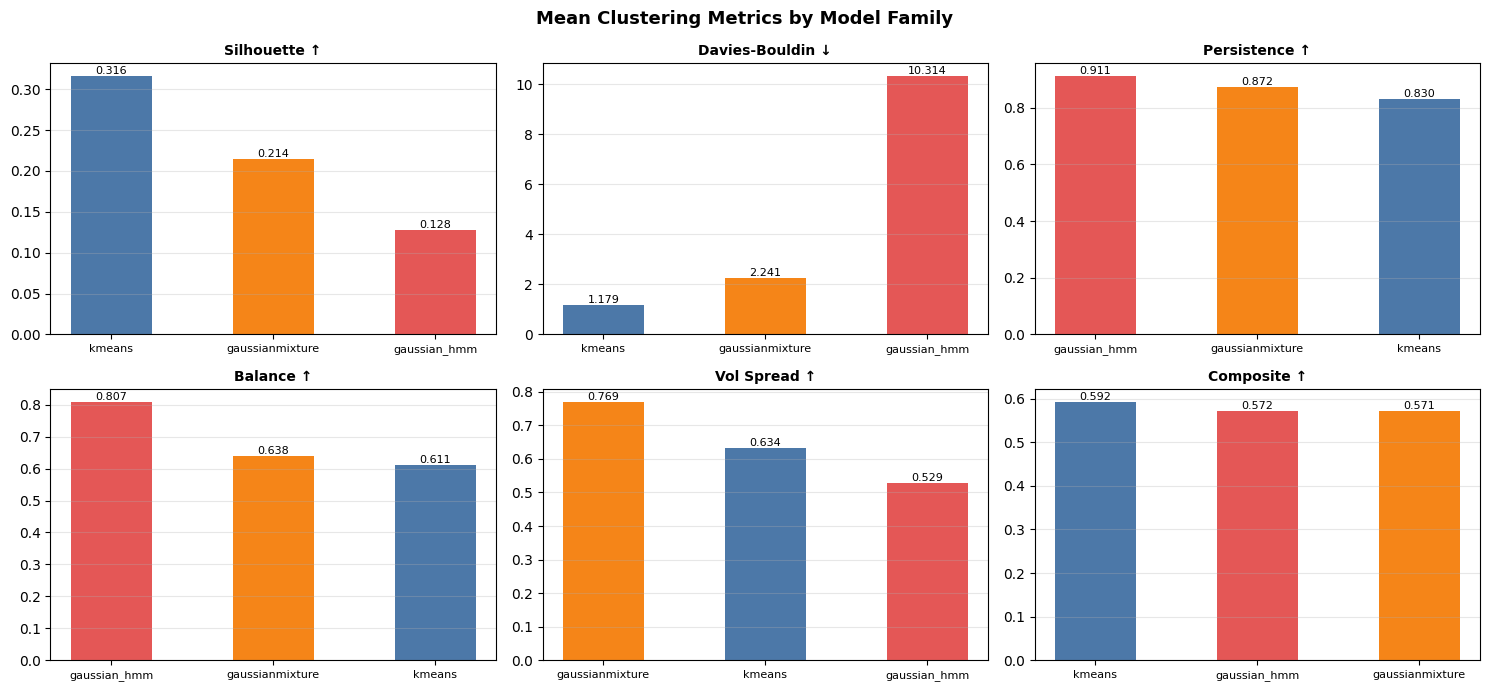

Feature set ranking by mean composite score:
feature_set
vol_only          0.6380
price_vol         0.6021
minimal           0.5914
momentum_vol      0.5299
full_stationary   0.5173


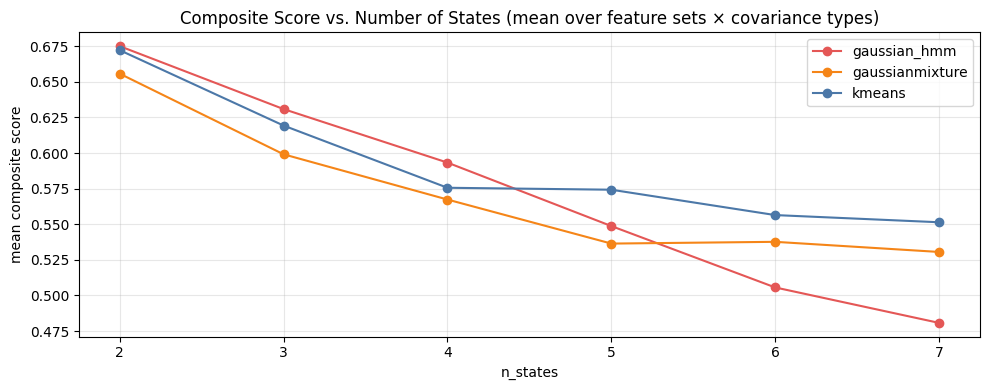

In [ ]:
# ── Metric breakdown: model family comparison ─────────────────────────────────

COLORS = {'kmeans': '#4C78A8', 'gaussianmixture': '#F58518', 'gaussian_hmm': '#E45756'}
METRICS = ['silhouette', 'davies_bouldin', 'persistence', 'balance', 'vol_spread', 'composite']
TITLES  = ['Silhouette ↑', 'Davies-Bouldin ↓', 'Persistence ↑', 'Balance ↑', 'Vol Spread ↑', 'Composite ↑']

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, metric, title in zip(axes.flat, METRICS, TITLES):
    agg  = results.groupby('model_family')[metric].mean()
    agg  = agg.sort_values(ascending=(metric == 'davies_bouldin'))
    bars = ax.bar(agg.index, agg.values, color=[COLORS.get(f, '#aaa') for f in agg.index], width=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, agg.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Mean Clustering Metrics by Model Family', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature set ranking
print("Feature set ranking by mean composite score:")
print(results.groupby('feature_set')['composite'].mean()
      .sort_values(ascending=False)
      .to_string(float_format=lambda x: f'{x:.4f}'))

# Composite score vs n_states
ns_agg = results.groupby(['model_family', 'n_states'])['composite'].mean().reset_index()
fig2, ax = plt.subplots(figsize=(10, 4))
for fam, grp in ns_agg.groupby('model_family'):
    ax.plot(grp['n_states'], grp['composite'], marker='o', label=fam, color=COLORS.get(fam, '#aaa'))
ax.set_xlabel('n_states')
ax.set_ylabel('mean composite score')
ax.set_title('Composite Score vs. Number of States (mean over feature sets × covariance types)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Best Model — Full Dataset

The winning configuration from the grid search is refit on the full sample to produce one regime label per bar. States are relabelled by median `rv_12`: lowest-vol state becomes `low`, highest-vol state becomes `high`, and intermediate states become `transition` (for 3-state models) or `mid_1`, `mid_2`, ...

Post-refit diagnostics are reported in sequence:
1. **Regime composition** — bar counts, regime share, and volatility moments.
2. **Run-length behaviour** — average and percentile duration per regime.
3. **Breakout incidence** — up/down channel breaks per regime using a one-bar-shifted trailing window to avoid lookahead.


In [ ]:
# ── Refit best model on full dataset ─────────────────────────────────────────

b_fam  = str(best['model_family'])
b_n    = int(best['n_states'])
b_cov  = str(best['cov'])
b_cols = list(FEATURE_SETS[str(best['feature_set'])])

_full = full_df.copy().sort_values('t_grid').reset_index(drop=True)
sc_full = StandardScaler()
X_full  = sc_full.fit_transform(_full[b_cols])

if b_fam == 'kmeans':
    _m = KMeans(n_clusters=b_n, n_init=30, random_state=7)
    _full['_state'] = _m.fit_predict(X_full)
elif b_fam == 'gaussianmixture':
    _m = GaussianMixture(n_components=b_n, covariance_type=b_cov, n_init=5, random_state=7)
    _m.fit(X_full);  _full['_state'] = _m.predict(X_full)
elif b_fam == 'gaussian_hmm':
    _m = GaussianHMM(n_components=b_n, covariance_type=b_cov, n_iter=200, random_state=7)
    _m.fit(X_full);  _full['_state'] = _m.predict(X_full)

# Map states → semantic labels by median rv_12
state_rv = _full.groupby('_state')['rv_12'].median().sort_values()
n_st     = len(state_rv)
if n_st == 1:
    label_map = {state_rv.index[0]: 'high'}
elif n_st == 2:
    label_map = {state_rv.index[0]: 'low', state_rv.index[-1]: 'high'}
elif n_st == 3:
    label_map = {state_rv.index[0]: 'low', state_rv.index[1]: 'transition', state_rv.index[-1]: 'high'}
else:
    label_map = {state_rv.index[0]: 'low', state_rv.index[-1]: 'high'}
    for i, idx in enumerate(state_rv.index[1:-1], 1):
        label_map[idx] = f'mid_{i}'

_full['regime'] = _full['_state'].map(label_map)

# Regime statistics
reg_stats = (
    _full.groupby('regime')['rv_12']
    .agg(count='count', rv_median='median', rv_mean='mean', rv_std='std')
    .assign(pct=lambda d: d['count'] / d['count'].sum())
)
print(f"Best model: {b_fam}  n={b_n}  cov={b_cov}  features={b_cols}\n")
print(reg_stats.to_string(float_format=lambda x: f'{x:.4f}'))


Best model: kmeans  n=2  cov=n/a  features=['rv_zscore', 'trend_gap_12']

        count  rv_median  rv_mean  rv_std    pct
regime                                          
high     6670     0.6305   0.9287  1.1186 0.0952
low     63359     0.0928   0.1517  0.1994 0.9048


In [ ]:
# ── Regime duration (run-length) analysis ────────────────────────────────────

rle        = (_full['regime'] != _full['regime'].shift()).cumsum()
run_lens   = _full.groupby(rle).size().rename('bars')
run_regime = _full.groupby(rle)['regime'].first()
run_df     = pd.DataFrame({'regime': run_regime.to_numpy(), 'bars': run_lens.to_numpy()})

step_sec     = float(_full['datetime'].diff().dt.total_seconds().dropna().median())
min_per_bar  = step_sec / 60.0

dur = (
    run_df.groupby('regime')['bars']
    .agg(
        n_runs='count',
        avg_bars='mean',
        median_bars='median',
        p10_bars=lambda s: s.quantile(0.10),
        p90_bars=lambda s: s.quantile(0.90),
    )
    .assign(
        avg_min=lambda d: d['avg_bars']    * min_per_bar,
        p10_min=lambda d: d['p10_bars']    * min_per_bar,
        p90_min=lambda d: d['p90_bars']    * min_per_bar,
    )
)

print("Regime duration statistics:")
print(dur[['n_runs', 'avg_bars', 'median_bars', 'p10_bars', 'p90_bars', 'avg_min', 'p10_min', 'p90_min']]
      .to_string(float_format=lambda x: f'{x:.1f}'))


Regime duration statistics:
        n_runs  avg_bars  median_bars  p10_bars  p90_bars  avg_min  p10_min  p90_min
regime                                                                              
high       738       9.0         10.0       1.0      17.0    135.6     15.0    255.0
low        739      85.7         42.0       1.0     255.4   1286.0     15.0   3831.0


Breakout definition: 96-bar trailing channel (shifted by 1 bar)
Evaluation rows: 70029 / 70029

Breakouts by regime:
         bars  up_breakouts  down_breakouts  total_breakouts  breakout_rate  up_share
regime                                                                               
low     63359          2558            1822             4380          0.069     0.584
high     6670           375             871             1246          0.187     0.301


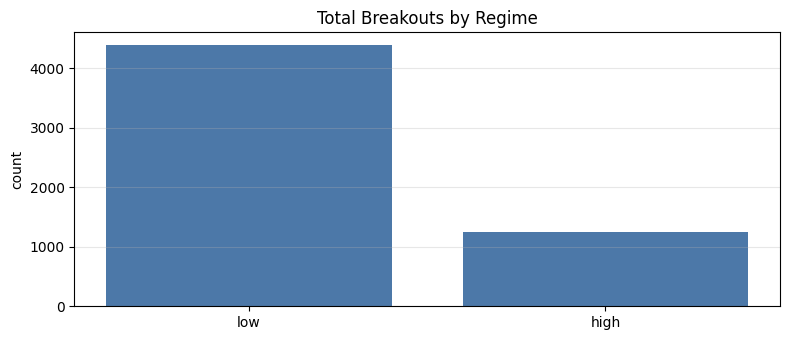

In [ ]:
# ── Breakouts by regime (best model labels) ───────────────────────────────────

# Define breakouts on 15m bars using trailing price-channel breaks:
# up_breakout   = close > rolling prior max(close)
# down_breakout = close < rolling prior min(close)

BREAKOUT_LOOKBACK_BARS = 96   # 24h at 15m bars
BREAKOUT_MIN_PERIODS   = 48

bo = _full[['datetime', 'und_mid', 'regime']].copy().sort_values('datetime').reset_index(drop=True)

roll_hi = bo['und_mid'].rolling(BREAKOUT_LOOKBACK_BARS, min_periods=BREAKOUT_MIN_PERIODS).max().shift(1)
roll_lo = bo['und_mid'].rolling(BREAKOUT_LOOKBACK_BARS, min_periods=BREAKOUT_MIN_PERIODS).min().shift(1)

bo['up_breakout'] = bo['und_mid'] > roll_hi
bo['dn_breakout'] = bo['und_mid'] < roll_lo
bo['is_breakout'] = bo['up_breakout'] | bo['dn_breakout']

# Drop warmup rows where channel is unavailable
bo_eval = bo.dropna(subset=['up_breakout', 'dn_breakout']).copy()

breakout_by_regime = (
    bo_eval.groupby('regime')
    .agg(
        bars=('regime', 'size'),
        up_breakouts=('up_breakout', 'sum'),
        down_breakouts=('dn_breakout', 'sum'),
        total_breakouts=('is_breakout', 'sum'),
    )
    .assign(
        breakout_rate=lambda d: d['total_breakouts'] / d['bars'],
        up_share=lambda d: np.where(d['total_breakouts'] > 0, d['up_breakouts'] / d['total_breakouts'], np.nan),
    )
    .sort_values('total_breakouts', ascending=False)
)

print(f"Breakout definition: {BREAKOUT_LOOKBACK_BARS}-bar trailing channel (shifted by 1 bar)")
print(f"Evaluation rows: {len(bo_eval)} / {len(bo)}")
print("\nBreakouts by regime:")
print(
    breakout_by_regime[
        ['bars', 'up_breakouts', 'down_breakouts', 'total_breakouts', 'breakout_rate', 'up_share']
    ].to_string(float_format=lambda x: f'{x:.3f}')
)

# Quick visual: total breakouts per regime
fig, ax = plt.subplots(figsize=(8, 3.5))
_break = breakout_by_regime['total_breakouts'].sort_values(ascending=False)
ax.bar(_break.index, _break.values, color='#4C78A8')
ax.set_title('Total Breakouts by Regime')
ax.set_ylabel('count')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


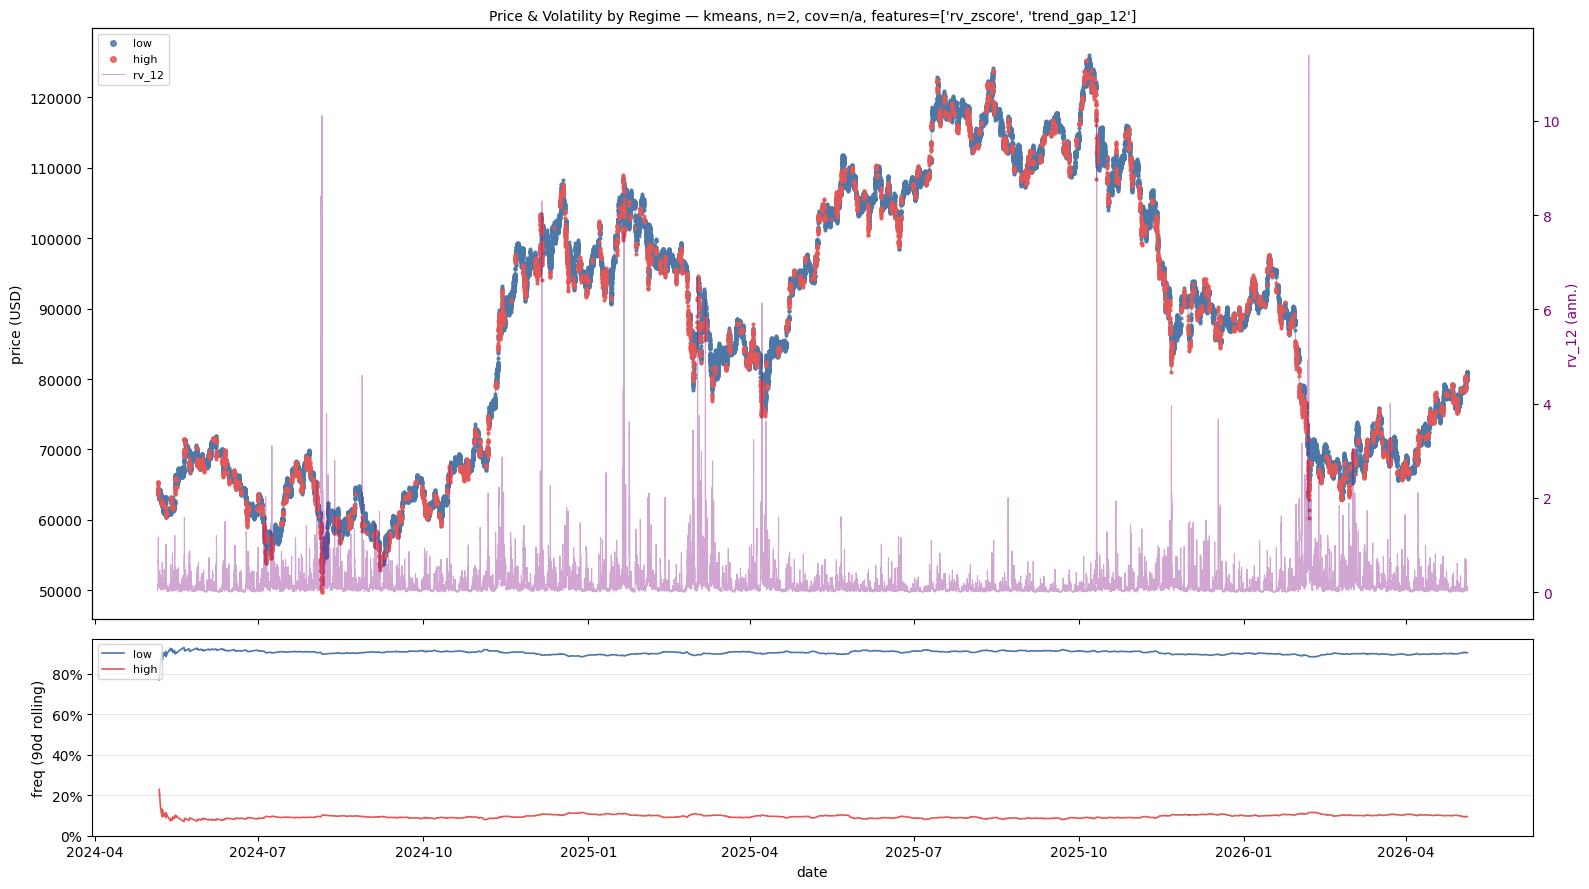

In [ ]:
# ── Plot: price (regime-coloured) + rv_12 + rolling regime frequency ─────────

REGIME_COLORS = {
    'low': '#4C78A8', 'transition': '#F58518', 'high': '#E45756',
    'mid_1': '#72B7B2', 'mid_2': '#B279A2', 'mid_3': '#FF9DA6',
}
FALLBACK_COLOR = '#AAAAAA'

plot = _full[['datetime', 'und_mid', 'rv_12', 'regime']].dropna().sort_values('datetime').copy()
all_regimes = (
    _full.groupby('regime')['rv_12'].median()
    .sort_values().index.tolist()
)

# Rolling 90-day regime frequency
bars_per_day = int(round(24 * 60 / 15))
roll_win     = 90 * bars_per_day
for r in all_regimes:
    plot[f'freq_{r}'] = (
        (plot['regime'] == r).astype(float)
        .rolling(roll_win, min_periods=bars_per_day).mean()
    )

fig, (ax1, ax3) = plt.subplots(
    2, 1, figsize=(16, 9), sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)
ax2 = ax1.twinx()

# Top panel: price scatter coloured by regime + rv_12 line
ax1.plot(plot['datetime'], plot['und_mid'], color='black', linewidth=0.7, alpha=0.35, zorder=1)
for r in all_regimes:
    c    = REGIME_COLORS.get(r, FALLBACK_COLOR)
    grp  = plot[plot['regime'] == r]
    ax1.scatter(grp['datetime'], grp['und_mid'], s=4, color=c, alpha=0.85, zorder=2, label=f'{r}')

ax2.plot(plot['datetime'], plot['rv_12'], color='purple', linewidth=0.8, alpha=0.35, zorder=0, label='rv_12')
ax1.set_ylabel('price (USD)')
ax2.set_ylabel('rv_12 (ann.)', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8, markerscale=2)
ax1.set_title(f'Price & Volatility by Regime — {b_fam}, n={b_n}, cov={b_cov}, features={b_cols}', fontsize=10)

# Bottom panel: rolling regime frequency
for r in all_regimes:
    ax3.plot(plot['datetime'], plot[f'freq_{r}'],
             color=REGIME_COLORS.get(r, FALLBACK_COLOR), linewidth=1.2, label=r)

ax3.set_ylabel('freq (90d rolling)')
ax3.set_xlabel('date')
ax3.set_ylim(0, None)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax3.legend(fontsize=8, loc='upper left')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Conclusion

This notebook selects a volatility-regime clustering model for BTCUSDT from a broad search over feature sets, model families, state counts, and covariance structures. The ranking objective combines six metrics so the chosen configuration is both geometrically well-separated and temporally stable.

**What matters most from the results:**

1. **Model structure matters.** HMM-type models are often strongest when regime transitions are gradual, because transition dynamics are modelled explicitly. KMeans is fast and interpretable, while Gaussian Mixture can represent richer cluster geometry but without temporal coupling.
2. **Feature design matters as much as algorithm choice.** Volatility-centric, stationary features typically produce the clearest regime separation. Rolling normalisation is essential; without it, raw level effects dominate clustering.
3. **State count is a trade-off.** Fewer states (2–3) generally give cleaner and more robust operational regimes, while larger state counts add granularity but can reduce persistence.
4. **Breakout diagnostics add behavioural context.** Counting up/down breakouts by inferred regime reveals where directional expansions are concentrated, which is directly useful for sizing rules, trade gating, and execution aggressiveness.

**Deployment guidance.** Refit on a rolling window, emit labels bar-by-bar, and keep stationarity/collinearity checks in the monitoring loop so regime boundaries remain meaningful as market structure evolves.
